# Vision-Language Model Explanation with shapiq

This notebook demonstrates how to explain a CLIP model's similarity between an image and a text
description using the new `shapiq.imputer.vision` sub-package.

**Pipeline overview:**

1. **Segmenter** divides the input into "players" (image patches, superpixels, text tokens).
2. **Masker** applies occlusion to a subset of those players.
3. **VisionImputer** orchestrates Segmenter → Masker → Model forward pass.
4. **VisionLanguageGame** adapts the imputer as a `shapiq.Game` for approximators.
5. Any **shapiq approximator** (e.g. `KernelSHAPIQ`) computes Shapley interaction values.

**Model:** `openai/clip-vit-base-patch32` — 7×7 = 49 image patches, 8 text players (CLIP BOS+EOS stripped).

In [23]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

import shapiq
from shapiq.imputer.vision import (
    SegmenterConfig,
    SlicParams,
    VisionImputerFactory,
    VisionLanguageGame,
)

## 1. Load Model & Processor

In [24]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Using device: {device}")
print(f"Image size: {model.config.vision_config.image_size}")
print(f"Patch size: {model.vision_model.embeddings.patch_size}")

Using device: cuda
Image size: 224
Patch size: 32


## 2. Load Input Image & Text

Uses the bundled sample image `tests/shapiq/data/dog_and_hydrant.png`.
Replace with your own image path for other experiments.

Image size: (511, 511)


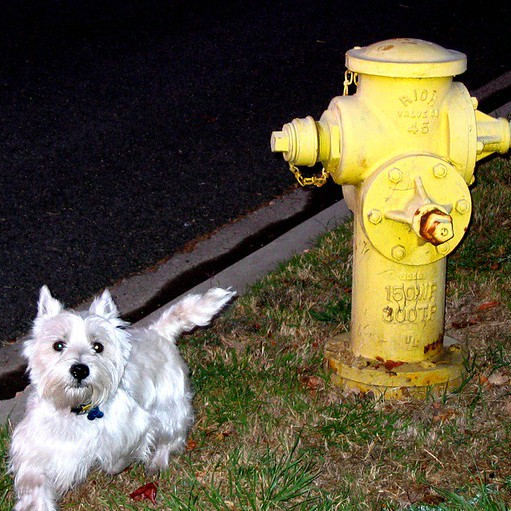

In [25]:
INPUT_TEXT = "black dog next to a yellow hydrant"

image_path = Path("tests") / "shapiq" / "data" / "dog_and_hydrant.png"
if not image_path.exists():
    image_path = Path("../../tests/shapiq/data/dog_and_hydrant.png")

image = Image.open(image_path).convert("RGB")
print(f"Image size: {image.size}")
display(image)

## 3. Build the Imputer Pipeline

`VisionImputerFactory` auto-detects the model type (`clip`), extracts vision dimensions
(image_size=224, patch_size=32 → 7×7 grid), preprocesses the text to count token players,
and assembles the default pipeline: **PatchSegmenter** + **CrossModalMeanMasker**.

In [26]:
factory = VisionImputerFactory()
imputer = factory.build(model, processor, image, INPUT_TEXT)

game = VisionLanguageGame(imputer, batch_size=64)

print(f"Model type:           {imputer.model_type}")
print(f"Image grid:           {imputer.grid_size}×{imputer.grid_size}")
print(f"Image players:        {game.n_players_image}")
print(f"Text players:         {game.n_players_text}")
print(f"Total players:        {game.n_players}")
print(f"Empty coalition:      {game.empty_value:.4f}")
print(f"Full coalition:       {game.full_value:.4f}")

Model type:           clip
Image grid:           7×7
Image players:        49
Text players:         8
Total players:        57
Empty coalition:      22.8664
Full coalition:       33.9399


## 4. Compute Shapley Interaction Values

We use `KernelSHAPIQ` with `k-SII` index and `max_order=2` to get both first-order
(Shapley values) and second-order (pairwise interaction) attributions.

Budget of 4096 coalitions is reasonable for 57 players and gives stable estimates.

In [27]:
approx = shapiq.KernelSHAPIQ(
    n=game.n_players,
    max_order=2,
    index="k-SII",
    random_state=42,
)

sii = approx.approximate(budget=2**12, game=game)
print(sii)

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=4096,
    n_players=57, baseline_value=-5.7220458984375e-06,
    Top 10 interactions:
        (55, 56): 2.253078544261407
        (18,): 1.8961962111082533
        (16, 27): 1.670675312296516
        (50, 51): 1.583923727937129
        (8, 55): 1.514953613291219
        (23, 24): -1.3969833487394763
        (34, 54): -1.4207458844932048
        (50,): -1.4873617365839036
        (36, 49): -1.5104322240537464
        (55,): -3.0554470196987165
)


## 5. Visualise Attributions

### 5a. Force Plot (First-Order)

Shows how each patch/token pushes the similarity score away from the baseline.

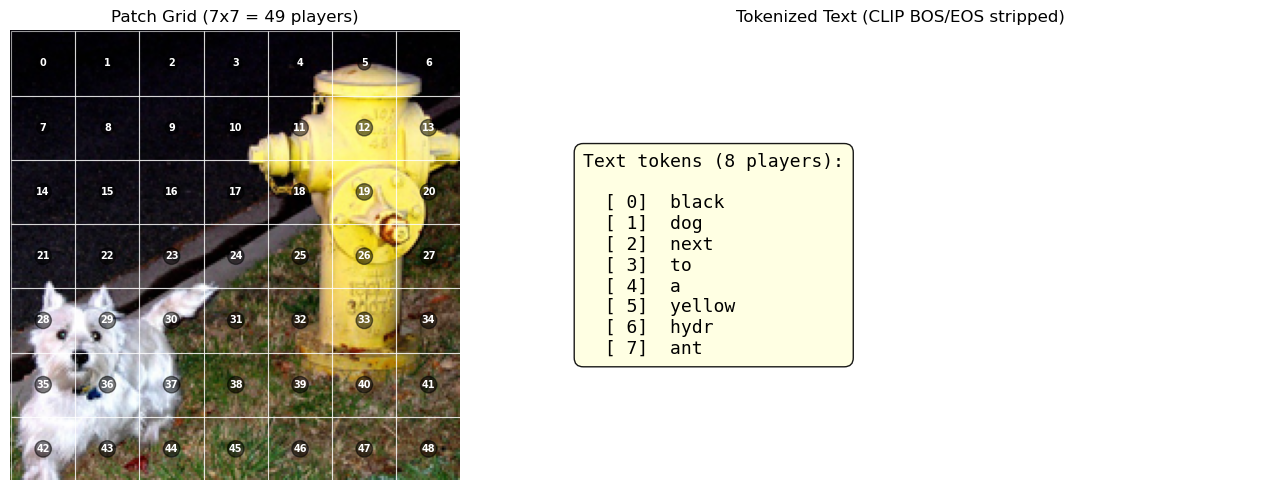

Input text: "black dog next to a yellow hydrant"
Number of image players: 49
Number of text players:  8
Total players:           57


In [28]:
# Visualize the 7x7 patch grid with player indices and the tokenized text

# -- Patch grid overlay on the input image --
grid_size = imputer.grid_size
patch_size = imputer.patch_size
img_resized = image.resize((grid_size * patch_size, grid_size * patch_size))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(img_resized)
# Draw grid + label each patch with its player index
for row in range(grid_size):
    for col in range(grid_size):
        idx = row * grid_size + col
        cx = col * patch_size + patch_size // 2
        cy = row * patch_size + patch_size // 2
        rect = plt.Rectangle(
            (col * patch_size, row * patch_size),
            patch_size,
            patch_size,
            fill=False,
            edgecolor="white",
            lw=0.8,
            alpha=0.6,
        )
        ax1.add_patch(rect)
        ax1.text(
            cx,
            cy,
            str(idx),
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.15", facecolor="black", alpha=0.5),
        )
ax1.set_title(f"Patch Grid ({grid_size}x{grid_size} = {game.n_players_image} players)")
ax1.axis("off")

# -- Tokenized text display --
text_tokens_raw = imputer.inputs_raw.tokens()
# Strip CLIP special tokens (BOS at [0], EOS at [-1]) and byte-Pair artifacts
text_tokens = [t.replace("</w>", "") for t in text_tokens_raw[1:-1]]

ax2.axis("off")
token_str = "\n".join([f"  [{i:2d}]  {tok}" for i, tok in enumerate(text_tokens)])
ax2.text(
    0.05,
    0.5,
    f"Text tokens ({game.n_players_text} players):\n\n{token_str}",
    transform=ax2.transAxes,
    fontsize=13,
    verticalalignment="center",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.9),
)
ax2.set_title("Tokenized Text (CLIP BOS/EOS stripped)")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f'Input text: "{INPUT_TEXT}"')
print(f"Number of image players: {game.n_players_image}")
print(f"Number of text players:  {game.n_players_text}")
print(f"Total players:           {game.n_players}")

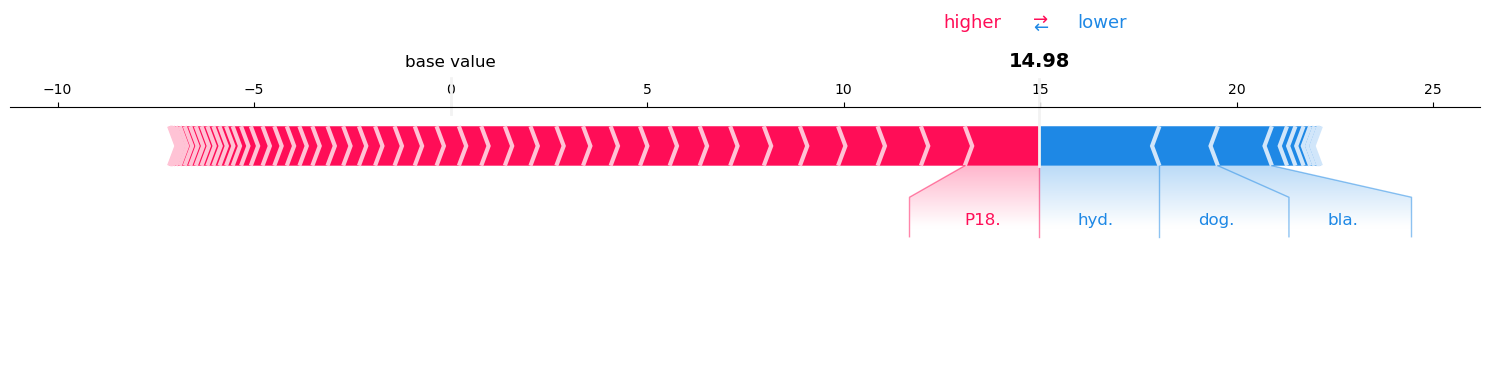

In [29]:
# Extract text token names (strip CLIP BOS/EOS)
text_tokens = imputer.inputs_raw.tokens()
text_tokens = [t.replace("</w>", "") for t in text_tokens[1:-1]]

feature_names = [f"P{i}" for i in range(game.n_players_image)] + text_tokens

sii_first_order = sii.get_n_order(1)
sii_first_order.plot_force(feature_names=feature_names)

### 5b. Interaction Network (Second-Order)

Edges show pairwise interactions between image patches and text tokens.
Blue = positive synergy (regions amplify each other), red = negative (they diminish each other).

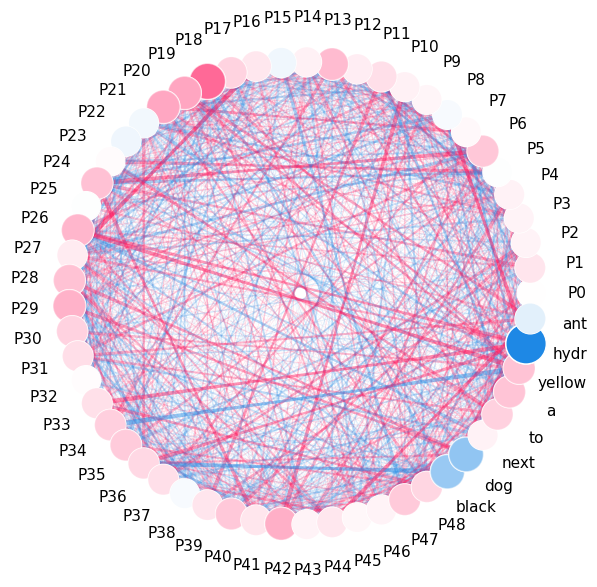

In [30]:
sii.plot_network(
    feature_names=feature_names,
    draw_threshold=0.0,
)

### 5c. Attribution Heatmap Overlay on Image

A custom visualisation maps first-order Shapley values back to the original image grid.
Green patches drive similarity **up** (important for the prediction); red patches drive it **down**.

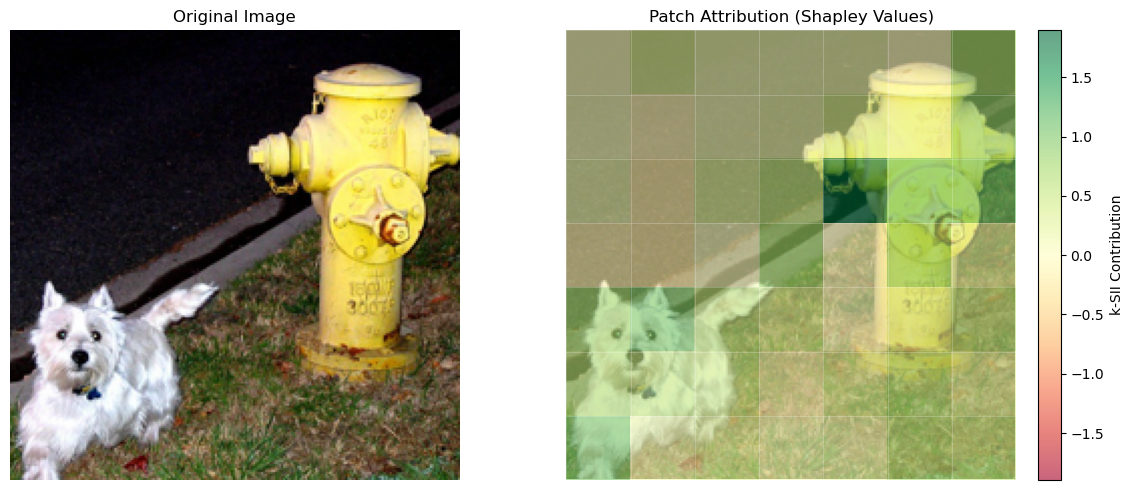

In [31]:
def plot_patch_overlay(
    image: Image.Image,
    sv: shapiq.InteractionValues,
    grid_size: int,
    patch_size: int,
    max_abs_val: float | None = None,
    alpha: float = 0.6,
    cmap: str = "RdYlGn",
) -> plt.Figure:
    """Overlay patch-level Shapley values on the input image."""
    img_resized = image.resize((grid_size * patch_size, grid_size * patch_size))
    values = np.array([sv[(i,)] for i in range(grid_size * grid_size)])
    grid = values.reshape(grid_size, grid_size)

    if max_abs_val is None:
        max_abs_val = max(abs(grid.min()), abs(grid.max()))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(img_resized)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(img_resized)
    im = ax2.imshow(
        grid,
        extent=(0, img_resized.width, img_resized.height, 0),
        cmap=cmap,
        vmin=-max_abs_val,
        vmax=max_abs_val,
        alpha=alpha,
    )

    # Draw patch boundaries
    for i in range(grid_size + 1):
        ax2.axhline(i * patch_size, color="white", lw=0.5, alpha=0.3)
        ax2.axvline(i * patch_size, color="white", lw=0.5, alpha=0.3)

    ax2.set_title("Patch Attribution (Shapley Values)")
    ax2.axis("off")
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label="k-SII Contribution")
    plt.tight_layout()
    return fig


fig = plot_patch_overlay(image, sii_first_order, imputer.grid_size, imputer.patch_size)
plt.show()

## 6. Try a Different Segmenter (SLIC Superpixels)

For CNN-based CLIP models (e.g. `RN50`), rigid patches create OOD artifacts.
SLIC superpixels follow content boundaries. Pass a custom `SegmenterConfig` to the factory.

In [32]:
seg_cfg = SegmenterConfig(
    strategy="slic",
    slic=SlicParams(n_segments=49, compactness=10.0, sigma=1.0),
)

slic_imputer = factory.build(
    model,
    processor,
    image,
    INPUT_TEXT,
    segmenter_config=seg_cfg,
)
slic_game = VisionLanguageGame(slic_imputer, batch_size=64)

print(f"SLIC segmenter — players: {slic_game.n_players_image}")
print(f"Empty: {slic_game.empty_value:.4f}, Full: {slic_game.full_value:.4f}")

SLIC segmenter — players: 36
Empty: 22.8664, Full: 33.9399


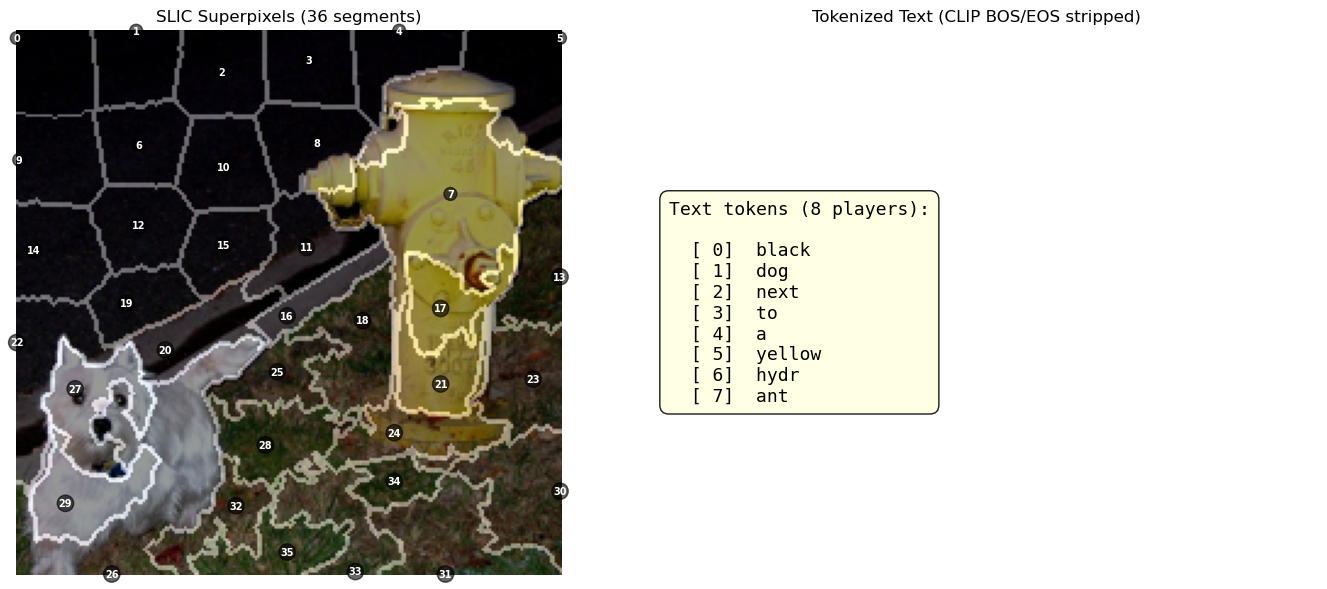

In [36]:
# Visualize SLIC superpixel boundaries with segment labels + tokenized text
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import find_boundaries

# Read the SLIC label map from the segmenter
slic_seg = slic_imputer.segmenter
label_map = slic_seg._label_map.cpu().numpy()  # (H, W) int64
n_segments = slic_game.n_players_image

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -- Left panel: superpixel boundaries with segment labels --
image_np = np.array(image.resize((224, 224)))
ax1.imshow(image_np)

# Draw thin boundaries in white
boundaries = find_boundaries(label_map, mode="outer")
ax1.imshow(boundaries, cmap="gray", alpha=0.4)

# Place each segment label at the interior point furthest from the boundary
for seg_id in range(n_segments):
    mask = label_map == seg_id
    if mask.sum() == 0:
        continue
    dist = distance_transform_edt(mask)
    interior_pt = np.unravel_index(dist.argmax(), dist.shape)
    cy, cx = interior_pt
    ax1.text(
        cx,
        cy,
        str(seg_id),
        ha="center",
        va="center",
        fontsize=7,
        color="white",
        fontweight="bold",
        bbox=dict(boxstyle="circle,pad=0.15", facecolor="black", alpha=0.6),
    )

ax1.set_title(f"SLIC Superpixels ({n_segments} segments)")
ax1.axis("off")

# -- Right panel: tokenized text display --
ax2.axis("off")
token_str = "\n".join([f"  [{i:2d}]  {tok}" for i, tok in enumerate(text_tokens)])
ax2.text(
    0.05,
    0.5,
    f"Text tokens ({game.n_players_text} players):\n\n{token_str}",
    transform=ax2.transAxes,
    fontsize=13,
    verticalalignment="center",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.9),
)
ax2.set_title("Tokenized Text (CLIP BOS/EOS stripped)")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=4096,
    n_players=44, baseline_value=-5.7220458984375e-06,
    Top 10 interactions:
        (7,): 3.856011031023063
        (42, 43): 3.6369673090315247
        (7, 42): 2.9090694929780545
        (0, 14): 2.2586235030125246
        (7, 43): 2.151280321942964
        (27, 37): 1.986191342162316
        (25, 42): 1.8267690536257468
        (31, 43): 1.7433597166248964
        (6, 17): -1.8447785859573418
        (42,): -2.408859758586204
)


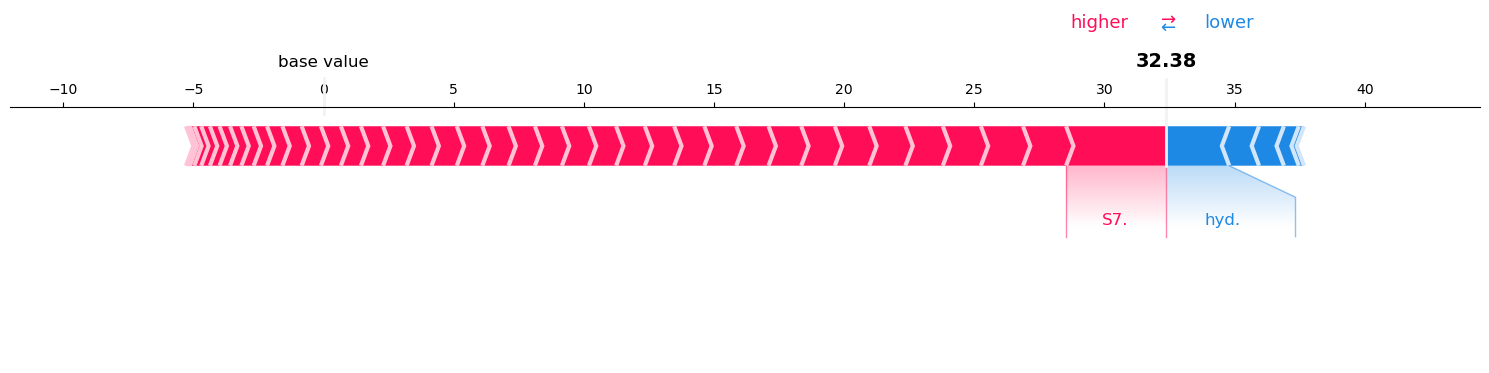

In [34]:
slic_approx = shapiq.KernelSHAPIQ(
    n=slic_game.n_players,
    max_order=2,
    index="k-SII",
    random_state=42,
)

slic_sii = slic_approx.approximate(budget=2**12, game=slic_game)
slic_fo = slic_sii.get_n_order(1)

print(slic_sii)
slic_fo.plot_force(feature_names=[f"S{i}" for i in range(slic_game.n_players_image)] + text_tokens)

## Summary

This notebook demonstrated the full `shapiq.imputer.vision` pipeline:

| Step | Component | What it does |
|---|---|---|
| Load model | `transformers` | CLIP ViT-B/32 |
| Segment | `PatchSegmenter` | 7×7 grid → 49 image players |
| Mask | `CrossModalMeanMasker` | Zero-out pixels + text attention |
| Orchestrate | `VisionImputer` | Batches coalitions, runs model forward |
| Adapt | `VisionLanguageGame` | Thin `shapiq.Game` wrapper |
| Approximate | `KernelSHAPIQ` (k-SII) | First- and second-order attributions |
| Visualise | shapiq + matplotlib | Force plot, network, custom heatmap |

To use your own image or text, simply change the `image` and `INPUT_TEXT` variables.
To switch segmenter/masker, pass a `SegmenterConfig` / `MaskerConfig` to the factory.